In [178]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

import warnings
warnings.filterwarnings('ignore')

In [179]:
df = pd.read_csv("student_health_data.csv")
df.head()

,Student_ID,Age,Gender,Heart_Rate,Blood_Pressure_Systolic,Blood_Pressure_Diastolic,Stress_Level_Biosensor,Stress_Level_Self_Report,Physical_Activity,Sleep_Quality,...,Health_Risk_Level,Family_members,Unnamed: 15,Unnamed: 16,Unnamed: 17,Unnamed: 18,Unnamed: 19,Unnamed: 20,Unnamed: 21,Unnamed: 22
0,1,24,M,50.663217,122.173015,84.419860,3.137350,9.028669,High,Moderate,...,Moderate,2,NaN,NaN,NaN,NaN,NaN,NaN,Yes,No
1,2,21,F,57.926042,110.778407,75.696145,3.699078,5.819697,Moderate,Good,...,Moderate,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3,22,M,59.294219,109.375673,83.803814,6.785156,5.892360,Low,Moderate,...,Moderate,12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4,24,M,76.826232,125.142227,78.091587,6.408509,6.884001,High,Poor,...,High,9,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5,20,M,68.342769,107.515592,80.674937,7.264719,4.483450,Moderate,Poor,...,Moderate,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [180]:
df.columns

Index(['Student_ID', 'Age', 'Gender', 'Heart_Rate', 'Blood_Pressure_Systolic',
       'Blood_Pressure_Diastolic', 'Stress_Level_Biosensor',
       'Stress_Level_Self_Report', 'Physical_Activity', 'Sleep_Quality',
       'Mood', 'Study_Hours', 'Project_Hours', 'Health_Risk_Level',
       'Family_members', 'Unnamed: 15', 'Unnamed: 16', 'Unnamed: 17',
       'Unnamed: 18', 'Unnamed: 19', 'Unnamed: 20', 'Unnamed: 21',
       'Unnamed: 22'],
      dtype='object')

In [181]:

df.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Student_ID                1000 non-null   int64  
 1   Age                       1000 non-null   int64  
 2   Gender                    1000 non-null   object 
 3   Heart_Rate                1000 non-null   float64
 4   Blood_Pressure_Systolic   1000 non-null   float64
 5   Blood_Pressure_Diastolic  1000 non-null   float64
 6   Stress_Level_Biosensor    1000 non-null   float64
 7   Stress_Level_Self_Report  1000 non-null   float64
 8   Physical_Activity         1000 non-null   object 
 9   Sleep_Quality             1000 non-null   object 
 10  Mood                      1000 non-null   object 
 11  Study_Hours               1000 non-null   float64
 12  Project_Hours             1000 non-null   float64
 13  Health_Risk_Level         1000 non-null   object 
 14  Family_me

In [182]:
df.describe()

,Student_ID,Age,Heart_Rate,Blood_Pressure_Systolic,Blood_Pressure_Diastolic,Stress_Level_Biosensor,Stress_Level_Self_Report,Study_Hours,Project_Hours,Family_members,Unnamed: 15,Unnamed: 16,Unnamed: 17,Unnamed: 18,Unnamed: 19,Unnamed: 20
count,1000.000000,1000.0000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,0.0,0.0,0.0,0.0,0.0,0.0
mean,500.500000,20.9600,70.101863,119.835380,79.854756,5.483909,5.361601,30.227037,14.887368,7.463000,NaN,NaN,NaN,NaN,NaN,NaN
std,288.819436,2.0036,9.544663,14.604307,9.641699,2.596108,2.550382,10.341060,4.888624,4.034465,NaN,NaN,NaN,NaN,NaN,NaN
min,1.000000,18.0000,50.000000,90.000000,60.000000,1.008491,1.002186,5.000000,0.000000,1.000000,NaN,NaN,NaN,NaN,NaN,NaN
25%,250.750000,19.0000,63.347970,109.386868,73.115420,3.270567,3.172409,23.262704,11.573503,4.000000,NaN,NaN,NaN,NaN,NaN,NaN
50%,500.500000,21.0000,70.330916,120.051654,79.651738,5.368891,5.234889,30.432767,14.765873,7.000000,NaN,NaN,NaN,NaN,NaN,NaN
75%,750.250000,23.0000,76.425149,130.397799,86.535640,7.674233,7.471178,37.245193,18.159167,11.000000,NaN,NaN,NaN,NaN,NaN,NaN
max,1000.000000,24.0000,99.650104,165.929204,107.659796,9.994153,9.964115,60.000000,32.720325,14.000000,NaN,NaN,NaN,NaN,NaN,NaN


In [183]:
df = df.drop(columns=[col for col in df.columns if "Unnamed" in col])
df = df.drop("Student_ID", axis=1)

In [184]:
df.isnull().sum()

Age                         0
Gender                      0
Heart_Rate                  0
Blood_Pressure_Systolic     0
Blood_Pressure_Diastolic    0
Stress_Level_Biosensor      0
Stress_Level_Self_Report    0
Physical_Activity           0
Sleep_Quality               0
Mood                        0
Study_Hours                 0
Project_Hours               0
Health_Risk_Level           0
Family_members              0
dtype: int64

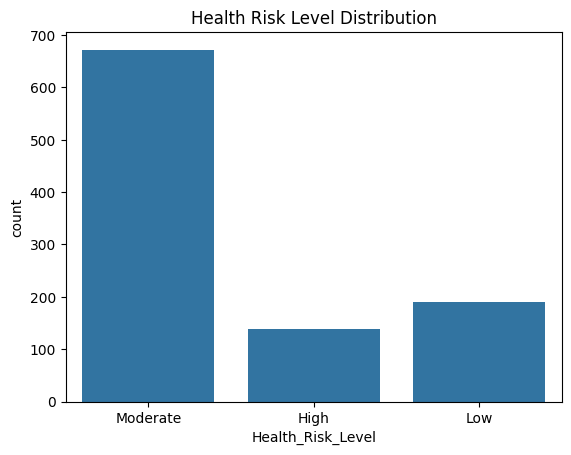

In [185]:

sns.countplot(x="Health_Risk_Level", data=df)
plt.title("Health Risk Level Distribution")
plt.show()

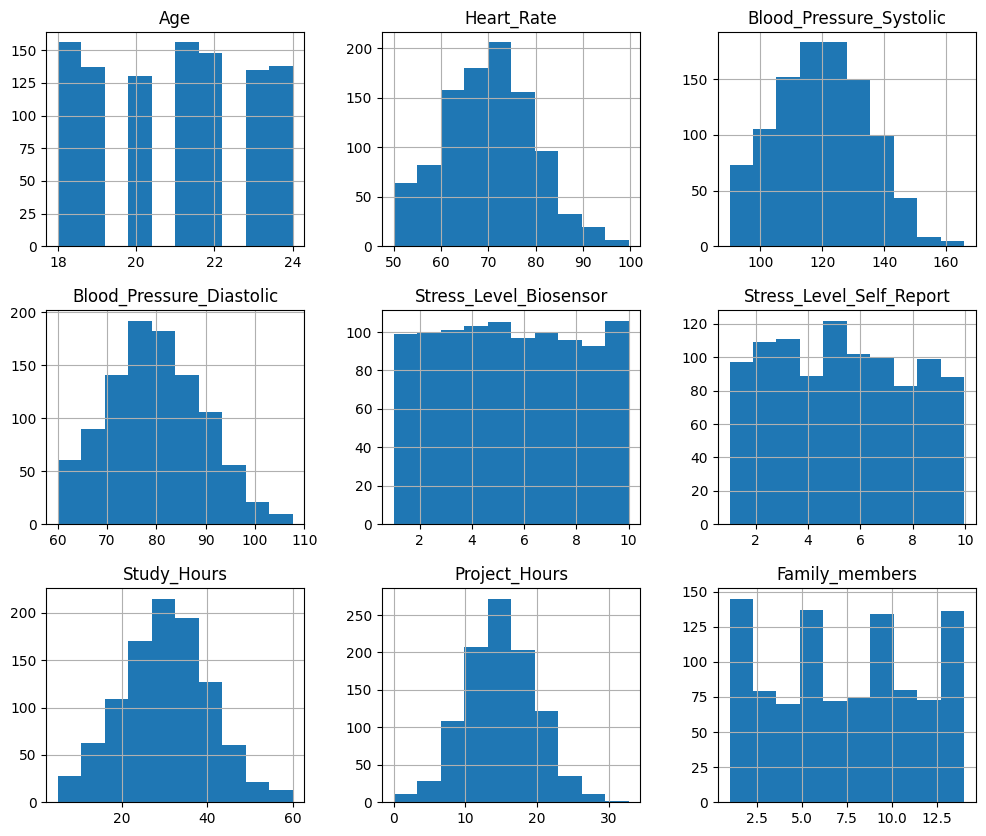

In [186]:
df.hist(figsize=(12,10))
plt.show()

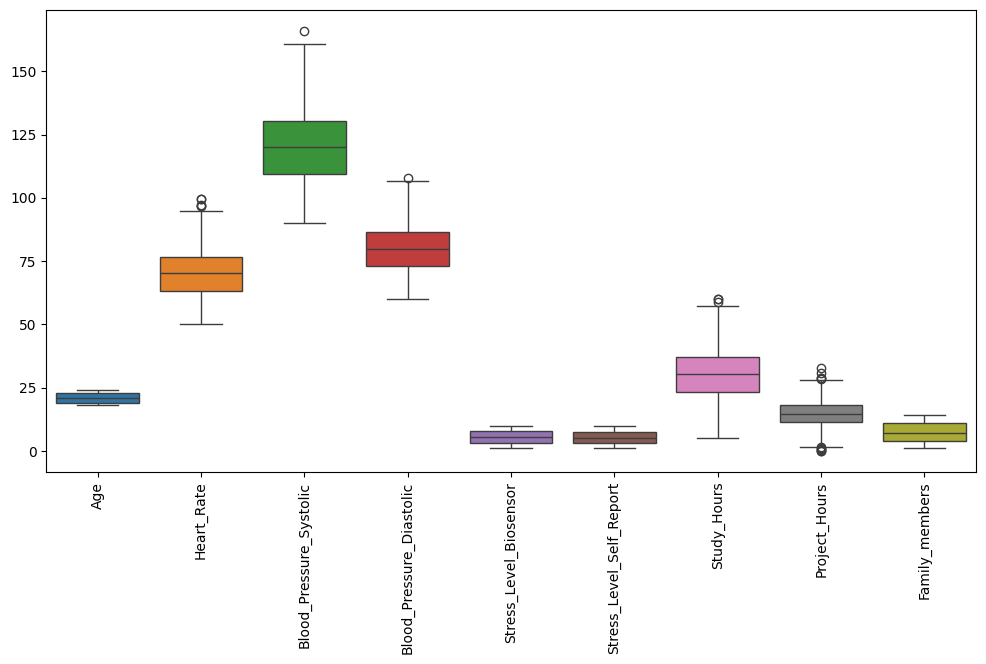

In [187]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df.select_dtypes(include=['int64','float64']))
plt.xticks(rotation=90)
plt.show()

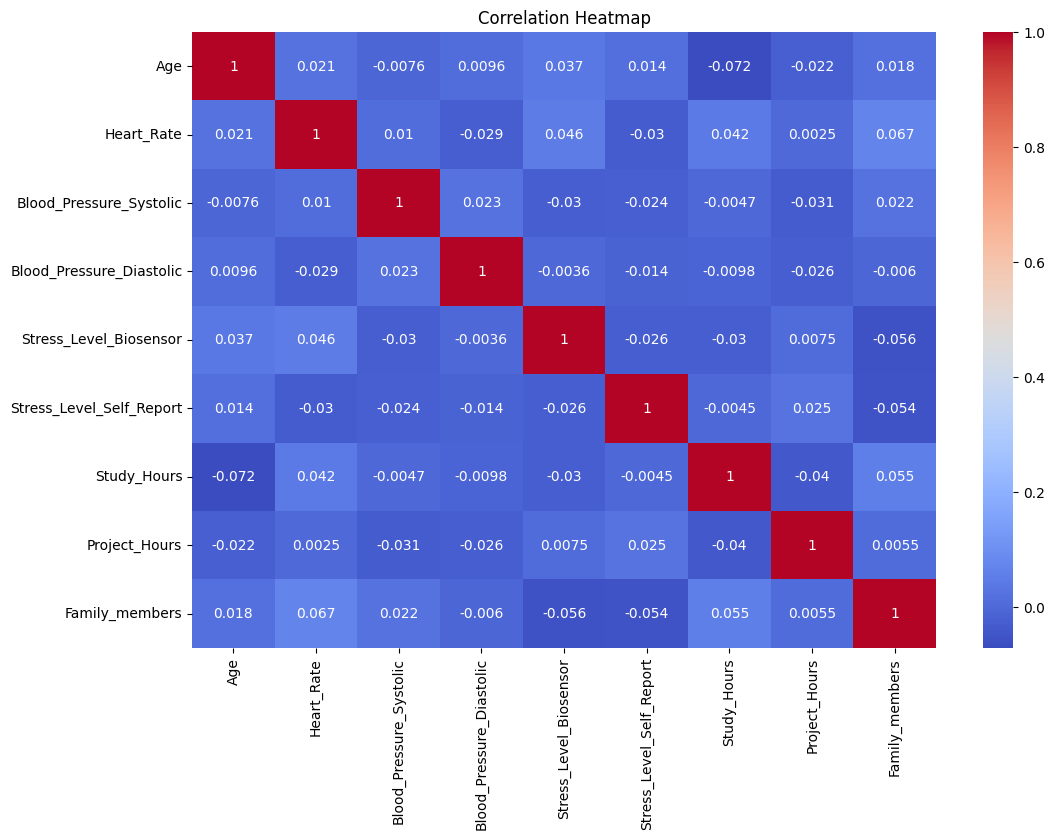

In [188]:
plt.figure(figsize=(12,8))
sns.heatmap(df.select_dtypes(include=['int64','float64']).corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

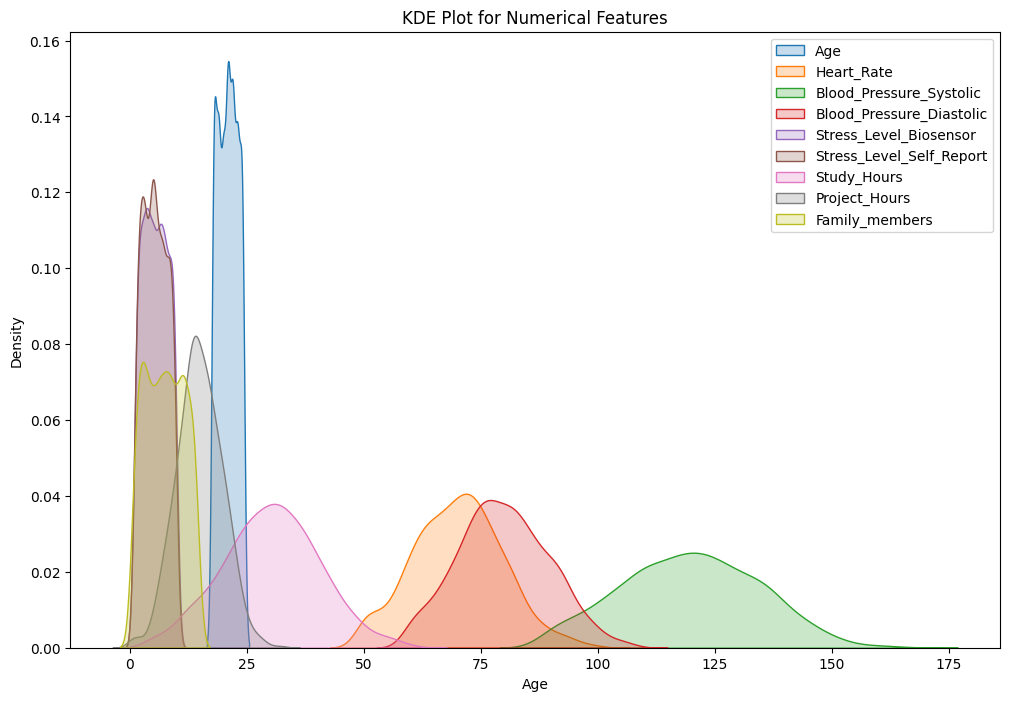

In [189]:
plt.figure(figsize=(12,8))

for col in df.select_dtypes(include=['int64','float64']).columns:
    sns.kdeplot(df[col], label=col, fill=True)

plt.legend()
plt.title("KDE Plot for Numerical Features")
plt.show()

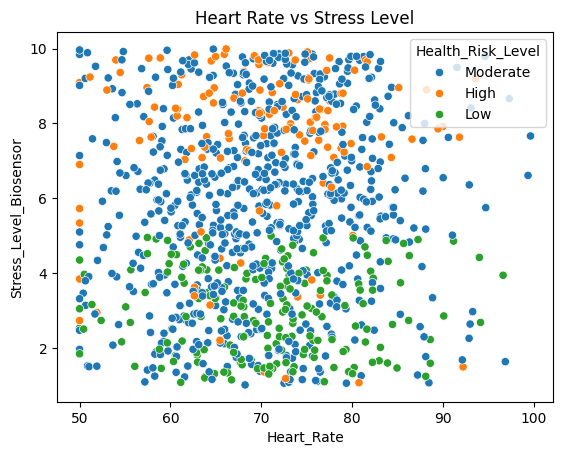

In [190]:
sns.scatterplot(x="Heart_Rate", y="Stress_Level_Biosensor", hue="Health_Risk_Level", data=df)
plt.title("Heart Rate vs Stress Level")
plt.show()

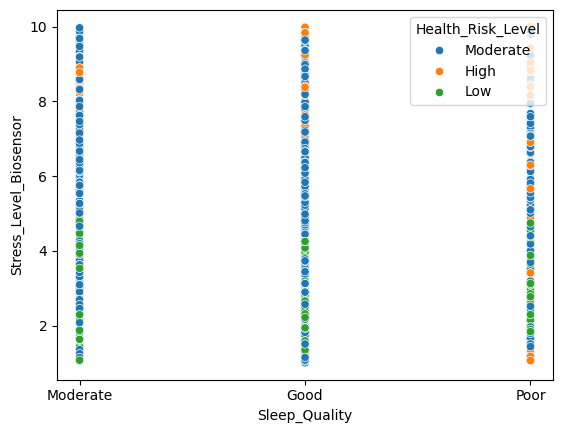

In [191]:
sns.scatterplot(x="Sleep_Quality", y="Stress_Level_Biosensor", hue="Health_Risk_Level", data=df)
plt.show()

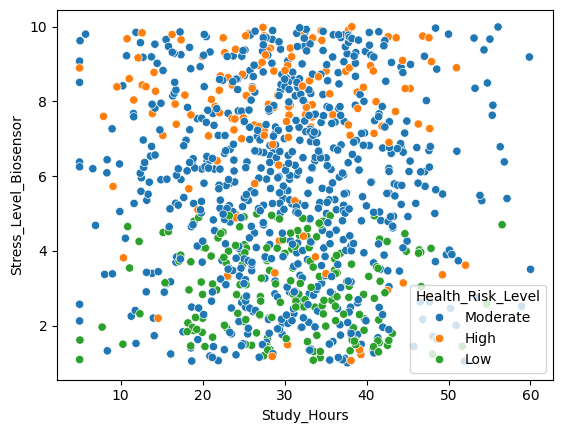

In [192]:
sns.scatterplot(x="Study_Hours", y="Stress_Level_Biosensor", hue="Health_Risk_Level", data=df)
plt.show()

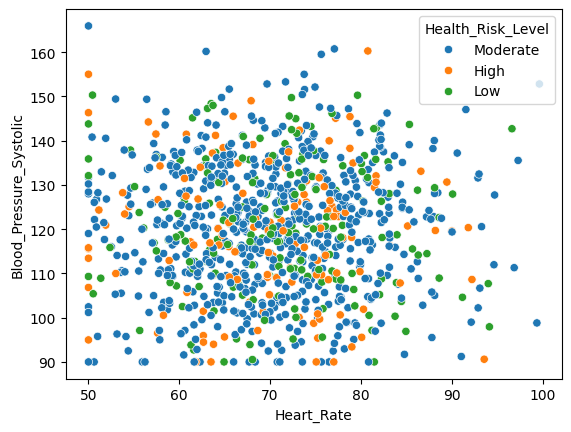

In [193]:
sns.scatterplot(x="Heart_Rate", y="Blood_Pressure_Systolic", hue="Health_Risk_Level", data=df)
plt.show()

In [194]:
X = df.drop("Health_Risk_Level", axis=1)
y = df["Health_Risk_Level"]

In [195]:
X = pd.get_dummies(X, drop_first=True)

In [196]:
X = X.fillna(X.mean(numeric_only=True))

In [197]:
le = LabelEncoder()
y = le.fit_transform(y)

In [198]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [199]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [200]:

models = {
    "Logistic Regression": LogisticRegression(),
    "Random Forest": RandomForestClassifier(),
    "SVM": SVC()
}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    
    print(f"{name} Accuracy: {acc}")

Logistic Regression Accuracy: 0.795
Random Forest Accuracy: 0.93
SVM Accuracy: 0.85


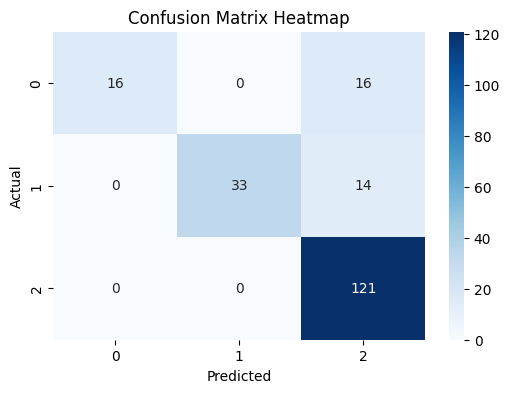

In [201]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix Heatmap")
plt.show()

In [202]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.50      0.67        32
           1       1.00      0.70      0.82        47
           2       0.80      1.00      0.89       121

    accuracy                           0.85       200
   macro avg       0.93      0.73      0.79       200
weighted avg       0.88      0.85      0.84       200



In [203]:
model = RandomForestClassifier()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [204]:
model = RandomForestClassifier()
model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [205]:
sample = X_test[1].reshape(1, -1)

prediction = model.predict(sample)

print("Predicted Class:", prediction)
print("Predicted Label:", le.inverse_transform(prediction))

Predicted Class: [1]
Predicted Label: ['Low']


In [206]:
import pickle

pickle.dump(model, open("health_model.pkl", "wb"))
pickle.dump(scaler, open("scaler.pkl", "wb"))
pickle.dump(le, open("label_encoder.pkl", "wb"))

In [207]:
model = pickle.load(open("health_model.pkl", "rb"))
scaler = pickle.load(open("scaler.pkl", "rb"))
le = pickle.load(open("label_encoder.pkl", "rb"))